### XÁC SUẤT THỐNG KÊ CHO AI

##### CHUẨN BỊ DỮ LIỆU

In [4]:
import numpy as np                  # Cài đặt thư viện numpy
import pandas as pd                 # Cài đặt thư viện pandas
import seaborn as sns               # Cài đặt thư viện seaborn
import matplotlib.pyplot as plt     # Cài đặt thư viện matplotlib
from scipy import stats
# Tải bộ dữ liệu Iris
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
iris_df = sns.load_dataset("iris")

##### PHẦN 1 - THỐNG KÊ MÔ TẢ & ĐẶC TRƯNG

>Đọc dữ liệu, hiển thị 5 dòng đầu; biểu diễn số dòng, số cột và kiểu dữ liệu của từng
cột.

In [ ]:
# Đọc dữ liệu, hiển thị 5 đầu dòng và hàng tiêu đề 
print("IRIS DATAFRAME:")
print(iris_df.head())
# In ra số hàng và số cột của dataFrame
number_row , number_col = iris_df.shape     # (iris_df.shape: trả về một Tuple (số hàng , số cột))
print(f"Number of row: {number_row} , number of col: {number_col}")
# Kiểu dữ liệu của từng cột
print("Kiểu dữ liệu của từng cột:")
print(iris_df.dtypes)

PHÂN TÍCH:
* Iris dataFrame gồm có:  150 dòng và 5 cột. Bốn cột đầu là: "sepal_length", "sepal_width", "petal_length", "petal_width" đều có kiểu "float64", cột cuối "species" là biến phân loại: setosa, versicolor, virginica.
* Không có "missing values".

>Tính mean, median, mode, var, std, min, max, Q1, Q3 và IQR

In [2]:
# Tách các cột có kiểu dữ liệu số của dataFrame và tạo danh sách chứa các tên cột
numeric_col = iris_df.select_dtypes(include = np.number).columns.tolist()
newDataFrame_row = []
for col in numeric_col:
    # Lấy danh sách dữ liệu ứng với mỗi cột
    col_list = iris_df[col]
    newDataFrame_row.append(
        {
            "Name_column" : col,
            "Mean"        : col_list.mean(),
            "Median"      : col_list.median(),
            "Mode"        : col_list.mode()[0],
            "Var"         : col_list.var(),
            "Std"         : col_list.std(),
            "Min"         : col_list.min(),
            "Max"         : col_list.max(),
            "Q1"          : col_list.quantile(0.25),
            "Q1"          : col_list.quantile(0.75),
            "IQR"         : col_list.quantile(0.75) - col_list.quantile(0.25)
        }
    )

# Tạo dataFrame mới để biểu diễn các giá trị vừa tính
dataFrame_statistical_index = pd.DataFrame(newDataFrame_row).set_index("Name_column")
print(dataFrame_statistical_index)

              Mean  Median  Mode   Var   Std   Min   Max    Q1   IQR
Name_column                                                         
sepal_length 5.843   5.800 5.000 0.686 0.828 4.300 7.900 6.400 1.300
sepal_width  3.057   3.000 3.000 0.190 0.436 2.000 4.400 3.300 0.500
petal_length 3.758   4.350 1.400 3.116 1.765 1.000 6.900 5.100 3.500
petal_width  1.199   1.300 0.200 0.581 0.762 0.100 2.500 1.800 1.500


>Theo từng loài, dùng "groupby" tính mean và std của từng biến số

In [ ]:
print("Mean theo loài:")    # Nhóm theo loài
mean_each_species = iris_df.groupby("species")[numeric_col].mean()
print(mean_each_species)
print("\nStd theo loài:")   # Nhóm theo loài
std_each_species = iris_df.groupby("species")[numeric_col].std()
print(std_each_species)

# Kỹ thuật tìm đặc trưng khác nhất
print("\nGiá trị mức độ phân tách của mỗi loài:")
most_different_feature = (mean_each_species.max() - mean_each_species.min()) / std_each_species.mean()
print(most_different_feature.sort_values(ascending = False))    # In ra các đặc trưng + mức độ phân tách của đặc trưng đó theo chiều giảm dần

Mean theo loài:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026

Std theo loài:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             0.352        0.379         0.174        0.105
versicolor         0.516        0.314         0.470        0.198
virginica          0.636        0.322         0.552        0.275

Giá trị mức độ phân tách của mỗi loài:
petal_length   10.264
petal_width     9.242
sepal_length    3.154
sepal_width     1.944
dtype: float64


NHẬN XÉT:
* Mức độ phân tách của đặc trưng càng lớn (các loài nằm đủ xa nhau và mỗi loài có dữ liệu co cụm, không tán rộng) thì có sự phân biệt giữa các loài càng cao:
    + "petal_length" và "petal_width" có mức độ phân tách giữa 3 loài lớn nhất nên được dùng để phân biệt các loài với nhau.
    + "sepal_length" và "sepal_width" có giá trị mean theo từng loài khá gần nhau nên
    mức độ phân tách nhỏ, đây là những giá trị gây nhiễu.

##### PHẦN 2 - PHÂN PHỐI XÁC SUẤT

>Vẽ histogram + KDE cho từng biến số

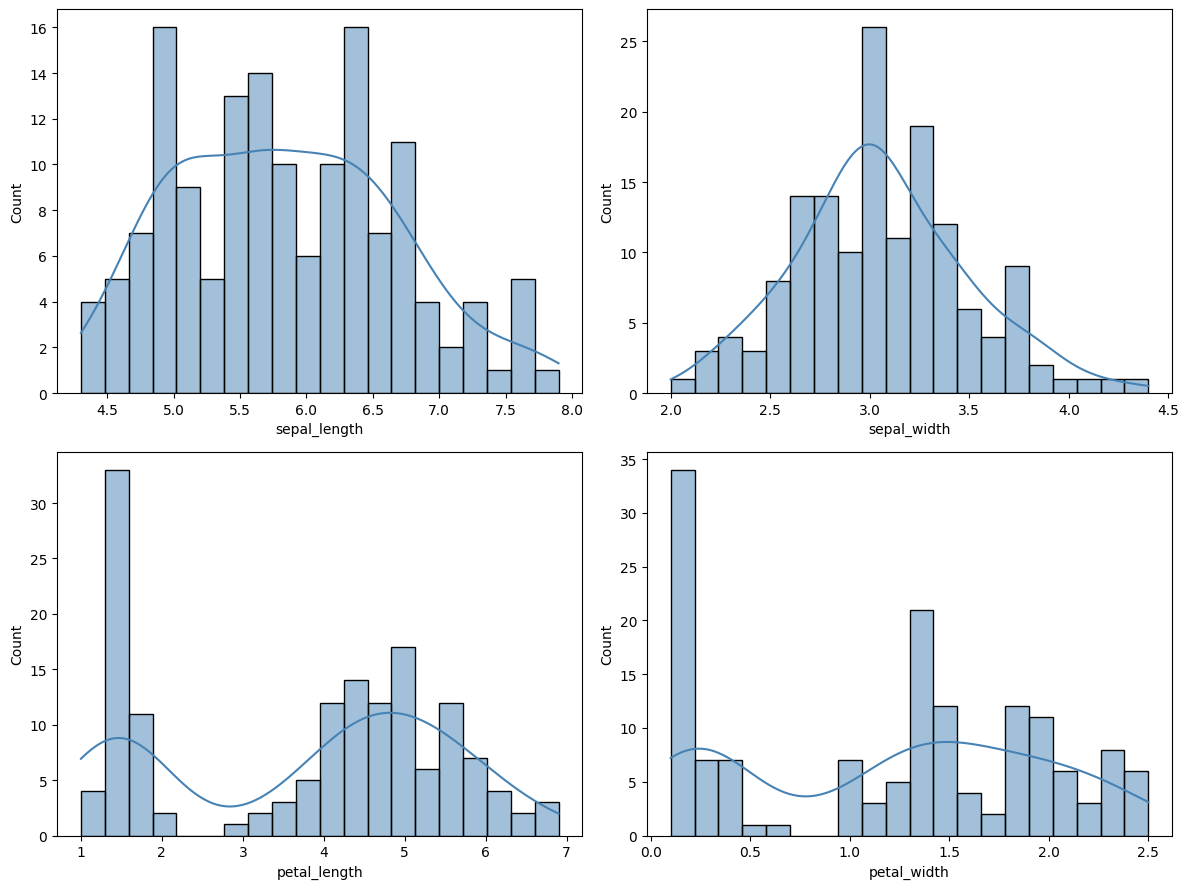

Độ lệch (skewness) của từng biến số:
sepal_length    0.315
sepal_width     0.319
petal_length   -0.275
petal_width    -0.103
dtype: float64


In [3]:
fig , axes = plt.subplots(2, 2, figsize = (12 , 9))
axes = axes.flatten()   # ép xuống thành 1 chiều để dễ tương tác với từng khung vẽ

# Vẽ histogram + KDE để biểu diễn dữ liệu
for ax , col in zip(axes, numeric_col):
    sns.histplot(data = iris_df, x = iris_df[col], ax = ax, color = "steelblue", kde = True, bins = 20)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# Tính độ lệch (skewness)
print("Độ lệch (skewness) của từng biến số:")
print(iris_df[numeric_col].skew())

NHẬN XÉT:
* Đồ thị biểu diễn "sepal_length" và "sepal_width" có 1 đỉnh và đều là những đồ thị lệch phải nhẹ; các giá trị phân bố đều quanh giá trị trung bình nên gần giống với phân phối chuẩn (skewness > 0)
* Đồ thị biểu diễn "pedal_length" và "pedal_width" có dạng hai đỉnh (Bimodal) và đều là những đồ thị lệch trái; các giá trị phân tán mạnh mà không tuân theo phân phối chuẩn (skewness < 0)

> Vẽ boxplot từng biến số theo loài

In [ ]:
fig , axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

# Vẽ boxplot theo loài:
for ax, col in zip(axes, numeric_col):
    # Nhóm dữ liệu theo loài, vẽ các box phân biệt nằm cách nhau dọc theo trục hoành
    sns.boxplot(data = iris_df, x = "species", y = col, ax = ax, hue = "species", legend = True)
plt.tight_layout()
plt.show()

NHẬN XÉT:
* "petal_length" và "petal_width" tách nhóm rất rõ giữa ba loài, đặc biệt "setosa" hoàn toàn nằm tách biệt (không chồng lấn) với hai loài còn lại.
* "versicolor" và "virginica" có chồng lấn một phần ở các biến số, nhưng vẫn phân biệt được qua giá trị trung vị (median). 
* "sepal_length" và "sepal_width" có nhiều chồng lấn nhất giữa 3 loài, khẳng định lại đây là biến số gây nhiễu.

> Sinh mẫu từ phân phối Normal có cùng mean và std với dữ liệu thực

In [ ]:
chosen_feature = "sepal_width"          # chose a feature
data_of_feature = iris_df[chosen_feature].values   # make a number array
# Calculate mean and std of feature
feature_mean, feature_std = data_of_feature.mean(), data_of_feature.std()
print(f"Biến chọn: {chosen_feature} (mean = {feature_mean:.4f}, std = {feature_std:.4f})")

# Sinh mẫu giả lập từ phân phối Normal có cùng mean và std
np.random.seed(42)      # Dữ liệu random nhưng không thay đổi qua mỗi lần chạy code
simulated_normal = np.random.normal(loc = feature_mean, scale = feature_std, size = len(data_of_feature))
print(f"5 giá trị đầu của mẫu mô phỏng: {simulated_normal[:5]}")

Biến chọn: sepal_width (mean = 3.0573, std = 0.4344)
5 giá trị đầu của mẫu mô phỏng: [3.27311141 2.9972698  3.33869634 3.71895421 2.95561454]


> Vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết

In [ ]:
# Vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết
# Tạo mảng gồm 200 giá trị x trải đều trên khoảng giá trị (data_of_feature.min() - 1, data_of_feature.max() + 1)
x = np.linspace(data_of_feature.min() - 1, data_of_feature.max() + 1, 200)
# Tạo mảng gôm 200 giá trị, mỗi giá trị ứng giá trị hàm mật độ phân phối chuẩn tính theo x  
pdf_theoretical = stats.norm.pdf(x, feature_mean, feature_std)  

# Vẽ histogram và đường PDF lý thuyết
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data_of_feature, stat = "density", bins = 20, color = "steelblue", alpha = 0.6, label = "Dữ liệu thực tế (histogram)", ax = ax)
ax.plot(x, pdf_theoretical, color = "crimson", lw = 2, label = "PDF Normal lý thuyết")
ax.set_title(f"So sánh Phân phối thực tế và Normal lý thuyết: {chosen_feature}")
ax.set_xlabel(chosen_feature)
ax.legend()
plt.tight_layout()
plt.show()

# Kiểm định Shapiro-Wilk để đánh giá định lượng mức độ tuân theo phân phối chuẩn
stat, p_value = stats.shapiro(data_of_feature)
print(f"Shapiro-Wilk test: statistic = {stat:.4f}, p-value = {p_value:.4f}")

NHẬN XÉT:
* Quan sát trực tiếp, ta thấy histogram của "sepal_width" có hình chuông khá giống đường PDF Normal lý thuyết, không lệch quá mạnh.
* Kiểm chứng bằng Shapiro-Wilk: p_value = 0.1012 > 5% và statistic = 0.9849 (gần bằng 1), chứng tỏ rằng dữ liệu của biến số "sepal_width" tuân theo phân phối chuẩn, nhưng về mặt thống kê nó không hoàn toàn
là một phân phối chuẩn, mà có độ lệch nhẹ do sự chồng ghép của 3 nhóm loài.

##### PHẦN 3 - PHÂN TÍCH ĐA BIẾN & TƯƠNG QUAN

> Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số

In [5]:
cov_matrix = iris_df[numeric_col].cov()         # Ma trận hiệp phương sai
corr_matrix = iris_df[numeric_col].corr()       # Ma trận tương quan

print("Ma trận hiệp phương sai (covariance):")
print(cov_matrix)

print("\nMa trận tương quan (correlation):")
print(corr_matrix)


Ma trận hiệp phương sai (covariance):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         0.686       -0.042         1.274        0.516
sepal_width         -0.042        0.190        -0.330       -0.122
petal_length         1.274       -0.330         3.116        1.296
petal_width          0.516       -0.122         1.296        0.581

Ma trận tương quan (correlation):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


NHẬN XÉT
* Ma trận hiệp phương sai và ma trận tương quan đều là ma trận vuông đối xứng
* Trên đường chéo chính của ma trận hiệp phương sai, giá trị càng lớn thì độ phân tán dữ liệu theo biến số càng nhiều (giá trị phương sai của biến số) - "pental_length".
* Các giá trị trên đường chéo chính của ma trận tương quan đều bằng 1 (mỗi biến số đều tương quan hoàn hảo với chính nó). Ô có giá trị càng lớn (càng gần bằng 1) thì hai biến số tương ứng càng tương quan hay thay đổi càng như nhau - (petal_length , petal_width).

> Vẽ heatmap tương quan

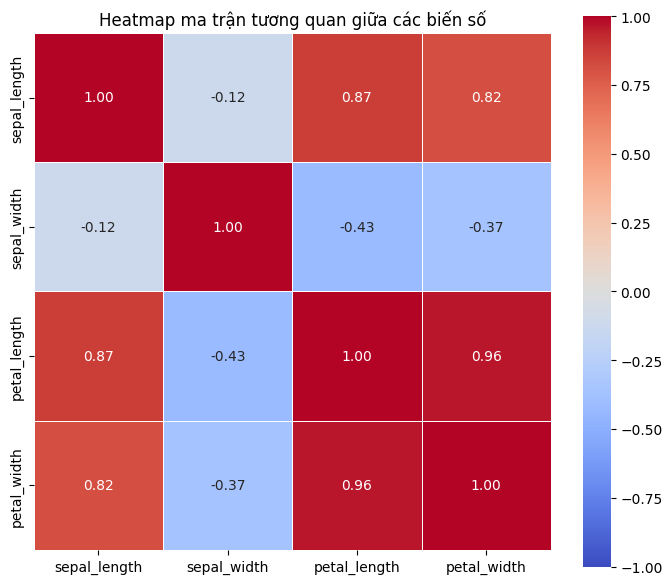

Cặp biến tương quan mạnh nhất: ('petal_length', 'petal_width') <-> r = 0.9629


In [6]:
# Vẽ heatmap tương quan
plt.figure(figsize=(7, 6))
# In giá trị lên các ô tương ứng, giới hạn thang đo màu sắc [-1 , 1], thang màu từ lạnh tới nóng
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1, square = True, linewidths = 0.5)
plt.title("Heatmap ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

# Tìm cặp biến tương quan mạnh nhất
# Ép ma trận thành series 1D (bỏ đi các ô đường chéo, có giá trị luôn bằng 1)
corr_unstacked = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).unstack()
strongest_pair = corr_unstacked.abs().idxmax()      # Tìm vị trí của ô có giá trị lớn nhất của series 1D vừa tạo
strongest_value = corr_unstacked[strongest_pair]    # In ra ô có giá trị lớn nhất đó 
print(f"Cặp biến tương quan mạnh nhất: {strongest_pair} <-> r = {strongest_value:.4f}")


**Có dấu hiệu đa cộng tuyến :** — vì "petal_length", "petal_width" và "sepal_length" có mức độ tương quan rất lớn với nhau (|r| > 0.8). Nếu dùng các biến số này làm đặc trưng đầu vào cho một mô hình hồi quy tuyến tính, cần lưu ý vấn đề đa cộng tuyến vì chúng gây khó khăn trong bóc tách từng biến số và tăng độ lệch chuẩn.

> Vẽ pairplot (scatter plot matrix), tô màu theo species

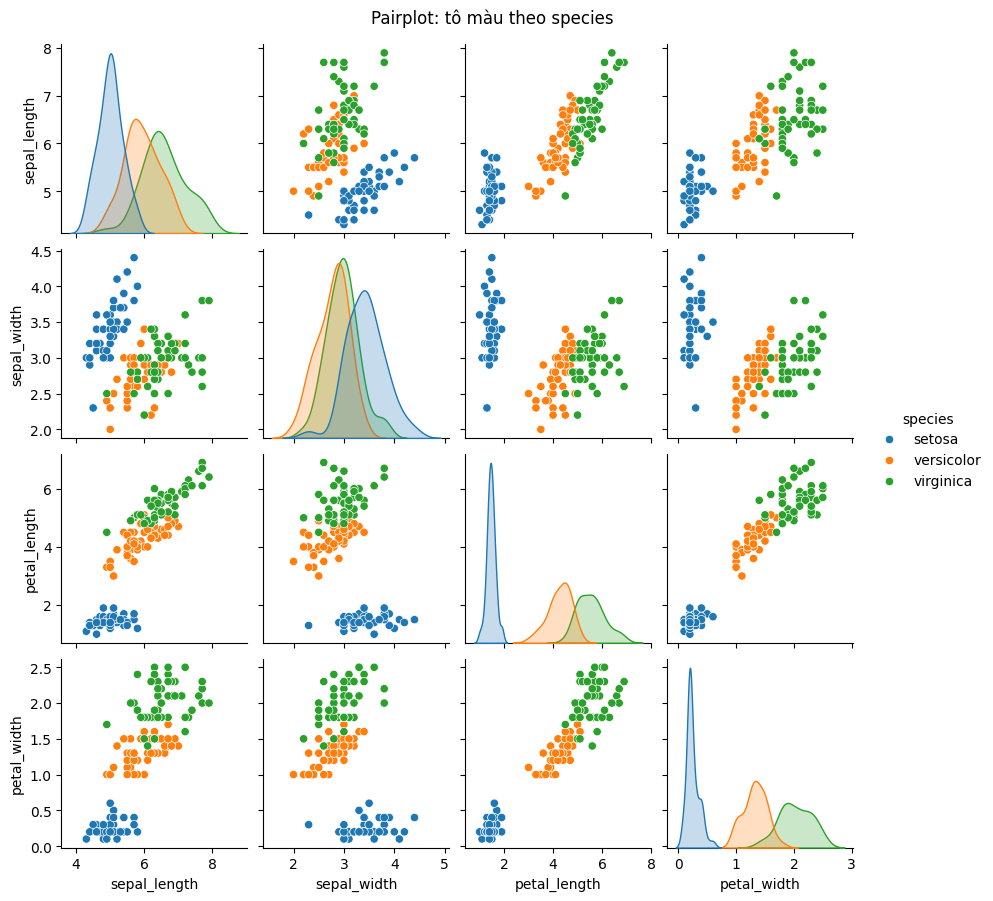

In [7]:
# Vẽ pairplot, gộp và tô màu theo nhóm
sns.pairplot(iris_df, diag_kind = 'kde', hue = "species", corner = False, height = 2.2)
plt.suptitle("Pairplot: tô màu theo species", y = 1.02)     # Đặt tiêu đề nằm cách các ô ở trên một khoảng
plt.show()

NHẬN XÉT:
* Từ các ô trên đường chéo chính, ta thấy với hai biến số "pental_length" và "pental_width": loài "setosa" phân phối tách biệt hẳn so với hai loài còn lại.
* Với các ô không nằm trên đường chéo chính, ta cũng thấy rõ sự tách biệt của đám mây dữ liệu đại diện cho loài "setosa" và hai loài còn lại; đặc biệt với các có hai biến số "pental_length" và "pental_width" cùng được xét đến: 3 đám mây dữ liệu đại diện cho 3 loài gần như tách biệt lẫn nhau và tạo hình dốc lên nên một lần nữa khẳng định, hai đặc trưng này rất có ích trong việc phân loại 3 loài hoa và tương quan rất mạnh với nhau

##### PHẦN 4 - Xác suất & Định lý Bayes

Cho:
- $P(B) = 0.01$ (tỉ lệ mắc bệnh trong dân số)
- $P(+ \mid B) = 0.99$ (độ nhạy — true positive rate)
- $P(+ \mid \neg B) = 0.05$ (dương tính giả — false positive rate)

Áp dụng định lý Bayes:
$$P(B \mid +) = \frac{P(+ \mid B) \, P(B)}{P(+ \mid B) P(B) + P(+ \mid \neg B)(1 - P(B))}$$

>Viết code tính xác suất hậu nghiệm $P(B \mid +)$ bằng định lý Bayes và in kết quả.

In [2]:
P_B = 0.01                      # P(B) : Tỉ lệ mắc bệnh trong dân số
P_pos_given_B = 0.99            # P(+|B) : Độ nhạy
P_pos_given_notB = 0.05         # P(+|not(B)) : Dương tính giả

# Tính giá trị của P(+) = P(+|B) * P(B) + P(+|not(B)) * P(not(B))
P_pos = P_pos_given_B * P_B + P_pos_given_notB * (1 - P_B)
# Tính giá trị của P(B|+) = P(+B) / P(+)
P_B_given_pos = P_pos_given_B * P_B / P_pos

print((f"P(B|+) = {round(P_B_given_pos , 4)}({P_B_given_pos*100:.2f}%)"))

P(B|+) = 0.1667(16.67%)


> Vẽ đồ thị P(B|+) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2.

In [3]:
# Tạo ra các giá trị p_B lưu trong mảng p_b thuộc (0.001 , 0.2) 
p_b = np.linspace(0.001, 0.2, 200)
# Tính toán với cơ chế của numpy
# Ứng với mỗi giá trị p_B trong mảng p_b: p_pos_range, p_b_given_pos_range lần lượt là mảng lưu các giá trị p_pos và p_b_given_pos tương ứng
p_pos_range = P_pos_given_B * p_b + P_pos_given_notB * (1 - p_b)     
p_b_given_pos_range = (P_pos_given_B * p_b) / p_pos_range

# Vẽ đồ thị:
plt.figure(figsize = (8 , 5))
plt.plot(p_b, p_b_given_pos_range, color = "steelblue", lw = 2, label = "Xác suất hậu nghiệm P(B|+) ứng với mỗi P(B)")
plt.xlabel("P(B) — tỉ lệ mắc bệnh trong dân số")
plt.ylabel("P(B | +) — xác suất hậu nghiệm")
plt.title("P(B | +) theo tỉ lệ mắc bệnh P(B)")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

**Giải thích vì sao khi bênh hiếm, kết quả lại "phản trực giác":**

- Khi $P(B)$ rất nhỏ (bệnh hiếm), số người không mắc bệnh trong dân số áp đảo số người mắc bệnh. Mặc dù tỉ lệ dương tính giả có giá trị nhỏ, nhưng khi áp dụng trên một nhóm dân số khỏe mạnh rất lớn, số lượng người khỏe mạnh bị dương tính giả vẫn có thể lớn hơn số người mắc bệnh thực sự cho kết quả dương tính đúng.

- Ví dụ cụ thể với $P(B) = 0.01$ và $P(+|\neg B)=0.05$: trong 10.000 người; khoảng 100 người mắc bệnh(99 người trong số đó dương tính đúng), nhưng trong 9.900 người khỏe mạnh, có khoảng $9900 \times 0.05 \approx 495$ người bị dương tính giả. Như vậy tổng số người dương tính là khoảng $99 + 495 = 594$ người, mà chỉ có 100 người trong đó thực sự mắc bệnh ($P(B|+) \approx 99/594 \approx 16.7\%$, khớp với kết quả tính được).

- Vì vậy, khi tỉ lệ mắc bệnh quá nhỏ, dù xét nghiệm có độ nhạy cao, kết quả dương tính vẫn không đủ để khẳng định mắc bệnh — cần xét nghiệm lại hoặc kết hợp thêm thông tin khác.

> Naive Bayes

In [11]:
# Dữ liệu huấn luyện (dùng để check những từ thường xuất hiện trong thư spam)
train_emails = [
    ("trung mai khuyen mai giam gia click ngay", "spam"),
    ("ban thang loi giai doc dac click de nhan", "spam"),
    ("khuyen mai mua hang giam gia hom nay", "spam"),
    ("hop nhom du an chieu nay luc 3 gio", "ham"),
    ("thong bao gui lai bao cao tien do du an cho thay nha", "ham"),
    ("nhac nho deadline bai tap ve nha tuan nay", "ham"),
]

# Tách các từ của một câu (cách nhau bởi khoảng trắng) thành một danh sách
def tokenize(text):
    return text.lower().split()

# Tính prior P(spam), P(ham)
labels = [lab for _, lab in train_emails]   # Labels chứa "spam" , "ham"
n_total = len(labels)                       # Đếm tổng số từ "spam" , "ham"      
n_spam = labels.count("spam")               # Đếm số số chữ "spam" trong dữ liệu huấn luyện
n_ham = labels.count("ham")                 # Đếm số số chữ "ham" trong dữ liệu huấn luyện
P_spam = n_spam / n_total       # P(spam)
P_ham = n_ham / n_total         # P(ham)

# Đếm tần suất xuất hiện của từ trong các emails
from collections import defaultdict         # defaultdict(int) tạo giá trị bằng 0 cho một giá trị chưa từng gặp

word_counts = {"spam": defaultdict(int), "ham": defaultdict(int)}
total_words = {"spam": 0, "ham": 0}
vocab = set()
for text, label in train_emails:
    for w in tokenize(text):
        word_counts[label][w] += 1
        total_words[label] += 1
        vocab.add(w)

V = len(vocab)      # V: tổng số từ (mỗi từ là duy nhất) tạo nên các emails
print(f"P(spam) = {P_spam:.3f}, P(ham) = {P_ham:.3f}")
print(f"Số lượng từ được huấn luyện: {V}")

# Laplace smoothing (Tránh các từ chưa từng gặp có P(w|spam) = 0, ta cộng thêm hệ số làm mịn alpha để chuẩn hoá tử và mẫu)
def word_prob(word, label, alpha=1.0):
    return (word_counts[label][word] + alpha) / (total_words[label] + alpha * V)

# Tránh underflow (nhân nhiều xác suất có giá trị < 1 khiến giá trị cuối cùng bị làm tròn về 0, ta dùng log())
def predict_spam_prob(text):
    words = tokenize(text)
    log_score_spam = np.log(P_spam)
    log_score_ham = np.log(P_ham)
    for w in words:
        log_score_spam += np.log(word_prob(w, "spam"))
        log_score_ham += np.log(word_prob(w, "ham"))
    # Chuẩn hoá về xác suất bằng softmax 2 lớp
    m = max(log_score_spam, log_score_ham)
    score_spam = np.exp(log_score_spam - m)
    score_ham = np.exp(log_score_ham - m)
    p_spam = score_spam / (score_spam + score_ham)
    return p_spam

# Các emails kiểm thử
test_emails = [
    "thay gui deadline bai tap ve nha hom nay, khuyen mai",
    "khuyen mai giam gia click ngay de nhan giai",
    "hop nhom de kiem tra mot lan nua du an",
    "deadline bai tap tuan nay, nho lam som"
]

print("\nDự đoán:")
for email in test_emails:
    p_spam = predict_spam_prob(email)
    label = "SPAM" if p_spam > 0.5 else "HAM"
    print(f" - \"{email}\"\n  P(spam|email) = {p_spam:.4f}, kết luận: {label}\n")


P(spam) = 0.500, P(ham) = 0.500
Số lượng từ được huấn luyện: 44

Dự đoán:
 - "thay gui deadline bai tap ve nha hom nay, khuyen mai"
  P(spam|email) = 0.2383, kết luận: HAM

 - "khuyen mai giam gia click ngay de nhan giai"
  P(spam|email) = 0.9999, kết luận: SPAM

 - "hop nhom de kiem tra mot lan nua du an"
  P(spam|email) = 0.1134, kết luận: HAM

 - "deadline bai tap tuan nay, nho lam som"
  P(spam|email) = 0.0574, kết luận: HAM



NHẬN XÉT:
+ Naive Bayes là một thuật toán "ngây thơ" không hiểu ý nghĩa văn bản, mà gom các dấu hiện, đặc trưng lại để đưa ra các quyết định phân loại.
+ Cũng chính vì thế, thuật toán đổi lại tốc độ và sự tối giản. Tuy nhiên, đôi khi dữ liệu huấn luyện còn ít, khiến một số email mục đích khuyến mãi (spam email) "lợi dụng" chèn thêm các từ hay gặp của (ham email) để đánh lừa thuật toán như ví dụ đầu tiên.